In [11]:
import sys
print(sys.executable)

c:\Users\thoma\AppData\Local\Programs\Python\Python310-32\python.exe


In [1]:
import os
from pathlib import Path
from collections import Counter
import hashlib

import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

RAW_DIR = Path("../data/raw")
CLASSES = ["cats", "dogs"]

plt.rcParams["figure.dpi"] = 100

In [2]:
records = []
corrupted = []

In [3]:
for label in CLASSES:
    folder = RAW_DIR / label
    for img_path in folder.glob("*.*"):
        try:
            with Image.open(img_path) as im:
                im.verify()
            records.append({"path": str(img_path), "label": label})
        except Exception as e:
            corrupted.append({"path": str(img_path), "error": str(e)})

c:\Users\thoma\miniconda3\envs\catsdogs\lib\site-packages\PIL\TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


In [4]:
df = pd.DataFrame(records)
print(f"Valid images: {len(df)}")
print(f"Corrupted images: {len(corrupted)}")

Valid images: 24998
Corrupted images: 0


In [ ]:
# Class balance
counts = df["label"].value_counts()
print("Class balance:\n", counts, "\nImbalance ratio:", round(counts.max()/counts.min(), 3))

# Sample 1500 για διαστάσεις/color mode/μέγεθος (γρήγορο)
sample_df = df.sample(min(1500, len(df)), random_state=42)
dims, modes, sizes = [], [], []
for p in sample_df["path"]:
    sizes.append(os.path.getsize(p)/1024)
    with Image.open(p) as im:
        w, h = im.size
        dims.append((w, h, w/h))
        modes.append(im.mode)

dims_df = pd.DataFrame(dims, columns=["width","height","aspect_ratio"])
print("\nDimensions:\n", dims_df.describe())
print("\nColor modes:", Counter(modes))
print("\nFile size KB - mean:", round(np.mean(sizes),1), "min:", round(min(sizes),1), "max:", round(max(sizes),1))

Class balance:
 label
cats    12499
dogs    12499
Name: count, dtype: int64 
Imbalance ratio: 1.0

Dimensions:
              width       height  aspect_ratio
count  1500.000000  1500.000000   1500.000000
mean    400.454667   360.628000      1.153448
std     108.346656   100.228133      0.299219
min      60.000000    37.000000      0.369159
25%     320.000000   300.000000      0.928000
50%     426.500000   375.000000      1.267162
75%     500.000000   432.250000      1.333333
max     500.000000   500.000000      2.752294

Color modes: Counter({'RGB': 1495, 'P': 5})

File size KB - mean: 32.8 min: 1.3 max: 395.7


In [6]:
#Duplicates 
def file_hash(p, bs=65536):
    h = hashlib.md5()
    with open(p, "rb") as f:
        for chunk in iter(lambda: f.read(bs), b""):
            h.update(chunk)
    return h.hexdigest()

hashes = {}
dupes = 0
for p in df["path"]:
    h = file_hash(p)
    if h in hashes: dupes += 1
    else: hashes[h] = p
print("Exact duplicates:", dupes)

Exact duplicates: 30


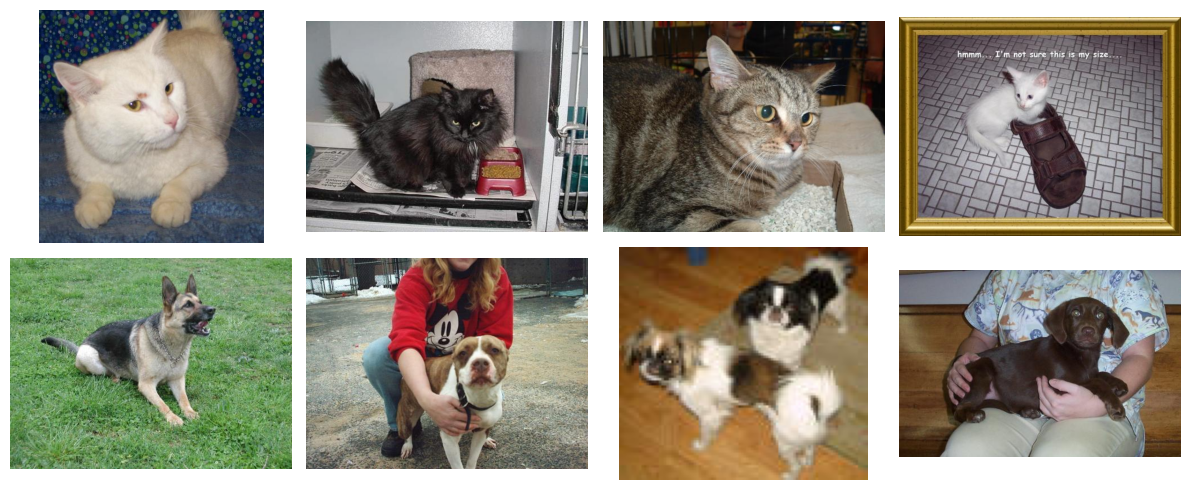

In [7]:
fig, axes = plt.subplots(2, 4, figsize=(12, 5))
for i, label in enumerate(CLASSES):
    for j, p in enumerate(df[df.label==label].sample(4, random_state=1)["path"]):
        axes[i,j].imshow(Image.open(p).convert("RGB")); axes[i,j].axis("off")
plt.tight_layout(); plt.show()

In [ ]:
#Split into train/val/test
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(df, train_size=0.8, stratify=df["label"], random_state=42)
val_df, test_df = train_test_split(temp_df, train_size=0.5, stratify=temp_df["label"], random_state=42)

Path("../data/processed").mkdir(parents=True, exist_ok=True)
train_df.to_csv("../data/processed/train.csv", index=False)
val_df.to_csv("../data/processed/val.csv", index=False)
test_df.to_csv("../data/processed/test.csv", index=False)
print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

Train: 19998 | Val: 2500 | Test: 2500


: 